# Importing a combined data

In [1]:
import pandas as pd
import os
from glob import glob
import seaborn as sns
import matplotlib.pyplot as plt
path = r"C:\Users\Nonso_Fidelis\Desktop\Nonso Fidelis 2026\stocks-data-main\cache\constituent_data"

files = glob(os.path.join(path, "*.csv"))

dfs = []

for file in files:
    df = pd.read_csv(file)
    ticker = os.path.basename(file).replace(".csv","")

    if "Symbol" not in df.columns:
        df["Symbol"] = ticker

    dfs.append(df)

stocks = pd.concat(dfs, ignore_index=True)

### Checking the look of the data

In [2]:
stocks.shape

(3508219, 7)

In [3]:
stocks.dtypes

Date       object
Symbol     object
Open      float64
High      float64
Low       float64
Close     float64
Volume    float64
dtype: object

In [4]:
stocks.head(2)

,Date,Symbol,Open,High,Low,Close,Volume
0,1999-11-18,A,29.5594,32.4842,25.9889,28.5858,6.886678e+07
1,1999-11-19,A,27.8972,27.9371,25.8613,26.2311,1.677358e+07


In [5]:
stocks["Date"] = pd.to_datetime(stocks["Date"])

In [6]:
stocks.head(2)

,Date,Symbol,Open,High,Low,Close,Volume
0,1999-11-18,A,29.5594,32.4842,25.9889,28.5858,6.886678e+07
1,1999-11-19,A,27.8972,27.9371,25.8613,26.2311,1.677358e+07


In [7]:
stocks.dtypes

Date      datetime64[ns]
Symbol            object
Open             float64
High             float64
Low              float64
Close            float64
Volume           float64
dtype: object

### Check for duplicated rows

In [8]:
stocks.duplicated().sum()

0

In [9]:
stocks = stocks.sort_values(["Symbol","Date"])
stocks

,Date,Symbol,Open,High,Low,Close,Volume
0,1999-11-18,A,29.5594,32.4842,25.9889,28.5858,6.886678e+07
1,1999-11-19,A,27.8972,27.9371,25.8613,26.2311,1.677358e+07
2,1999-11-22,A,26.8370,28.5858,26.0278,28.5858,7.242576e+06
3,1999-11-23,A,27.6102,28.3377,25.9889,25.9889,6.579458e+06
4,1999-11-24,A,26.0637,27.2445,25.9889,26.6745,5.332648e+06
...,...,...,...,...,...,...,...
3508214,2026-03-03,ZTS,127.7450,127.7500,125.2650,125.9500,1.383840e+05
3508215,2026-03-04,ZTS,126.1500,126.9000,124.9050,126.0150,2.324550e+05
3508216,2026-03-05,ZTS,124.8500,125.4100,122.0500,122.2200,2.237510e+05
3508217,2026-03-06,ZTS,120.1550,121.8300,118.3600,121.4150,1.677120e+05


## 1) Daily Price Variance - Using the high and low stock price variances to assess volatility

Daily Price Variance helps quantify the degree of intraday stock price fluctuations (difference between the highest and lowest prices), making it useful for assessing market volatility and identifying periods of increased trading risk or opportunity.

In [10]:
stocks["PriceVariance"] = (stocks["High"] - stocks["Low"])

In [11]:
stocks.head(2)

,Date,Symbol,Open,High,Low,Close,Volume,PriceVariance
0,1999-11-18,A,29.5594,32.4842,25.9889,28.5858,6.886678e+07,6.4953
1,1999-11-19,A,27.8972,27.9371,25.8613,26.2311,1.677358e+07,2.0758


## 2) Daily Return

Daily Return measures the percentage change in a stock's closing price from one trading day to the next, providing a standardized indicator of daily performance and helping identify trends, momentum, and volatility across different stocks.

In [12]:
stocks["DailyReturn"] = (stocks.groupby("Symbol")["Close"].pct_change())

In [13]:
stocks["DailyReturn"].head(2)

0         NaN
1   -0.082373
Name: DailyReturn, dtype: float64

## 3) Volatility Analysis - Volatility should be measured per stock.

Stock Volatility was calculated as the standard deviation of daily returns for each stock. This measure quantifies the degree of price fluctuation over time, allowing the identification of stocks with higher risk and uncertainty as well as those exhibiting more stable price behavior.

In [14]:
volatility = (stocks.groupby("Symbol")["DailyReturn"].std().reset_index())

In [15]:
volatility.head()

,Symbol,DailyReturn
0,A,0.025805
1,AAPL,0.026794
2,ABBV,0.016613
3,ABNB,0.029341
4,ABT,0.013634


## Most volatile stocks

Top 10 Most Volatile Stocks were identified by ranking stocks according to their volatility values in descending order. This analysis highlights the stocks that experienced the greatest fluctuations in daily returns, making them the highest-risk securities within the dataset and potentially offering greater opportunities for short-term trading gains or losses.

In [16]:
volatility.sort_values(by="DailyReturn",ascending=False).head(10)

,Symbol,DailyReturn
132,DD,0.181809
193,FITB,0.136346
235,HST,0.127021
44,AVB,0.125841
284,LII,0.124398
25,AMCR,0.099078
347,NUE,0.090988
134,DE,0.087251
417,SNDK,0.063416
125,CVNA,0.063044


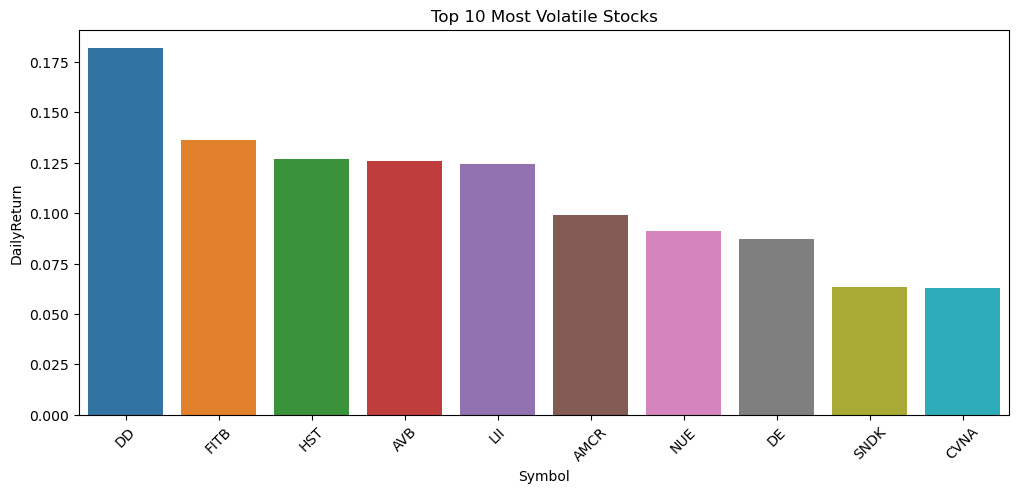

In [17]:
plt.figure(figsize=(12,5))
sns.barplot(data=volatility.sort_values('DailyReturn', ascending=False).head(10).reset_index(),x='Symbol',y='DailyReturn')
plt.title('Top 10 Most Volatile Stocks')
plt.xticks(rotation=45)
plt.show()

## Least Volatile Stocks

In [18]:
volatility.sort_values("DailyReturn").head(10)

,Symbol,DailyReturn
69,BRK.B,0.011045
491,WEC,0.012309
266,K,0.012483
419,SO,0.012648
128,D,0.012736
89,CHD,0.012887
43,ATO,0.013022
149,DTE,0.013044
494,WM,0.013197
13,AEP,0.013220


## Moving Averages - to identify potential trading opportunities

Two moving averages were computed for each stock: the 20-day Moving Average (MA20) and the 50-day Moving Average (MA50). The MA20 captures short-term price trends, while the MA50 reflects longer-term market movements. By comparing these moving averages, trend changes and potential buy or sell signals can be identified, as crossovers between the short-term and long-term averages often indicate shifts in market momentum. This analysis supports the project objective of identifying potential trading opportunities based on historical price behavior.

In [19]:
stocks["MA20"] = (stocks.groupby("Symbol")["Close"].rolling(20).mean().reset_index(level=0, drop=True))

stocks["MA50"] = (stocks.groupby("Symbol")["Close"].rolling(50).mean().reset_index(level=0, drop=True))

In [20]:
stocks.sample(5)

,Date,Symbol,Open,High,Low,Close,Volume,PriceVariance,DailyReturn,MA20,MA50
933407,2004-05-26,DD,15.68250,15.92800,15.58220,15.75400,7.083207e+06,0.3458,0.007456,15.496240,16.038304
3127410,2009-06-25,TPL,3.20653,3.45223,3.20653,3.29531,1.658620e+05,0.2457,0.012745,3.319442,3.013156
1829178,2024-06-17,JBL,119.47000,125.02000,119.12000,124.48000,1.919127e+06,5.9000,0.041848,118.287000,120.886400
1843,2007-03-28,A,21.62020,21.92720,21.55050,21.74980,3.942223e+06,0.3767,-0.004513,20.772200,20.983634
224618,2018-08-07,AMT,138.50900,138.50900,136.51600,137.71900,1.544658e+06,1.9930,-0.005983,132.808900,130.482780


# Trading Signals

Trading signals were derived using a moving average crossover strategy. A BUY signal was generated whenever the 20-day moving average (MA20) crossed above the 50-day moving average (MA50), suggesting a potential upward price trend. Conversely, a SELL signal was generated when the MA20 fell below the MA50, indicating a possible downward trend. This approach is widely used in technical analysis to identify potential entry and exit points in the market and supports the project's objective of detecting trading opportunities from historical stock price data.

In [21]:
stocks["Signal"] = ""

stocks.loc[stocks["MA20"] > stocks["MA50"],"Signal"] = "BUY"

stocks.loc[stocks["MA20"] < stocks["MA50"],"Signal"] = "SELL"

In [22]:
stocks.sample(5)

,Date,Symbol,Open,High,Low,Close,Volume,PriceVariance,DailyReturn,MA20,MA50,Signal
785756,2013-09-19,CPAY,111.5000,112.5000,110.10000,110.7300,4.046290e+05,2.40000,-0.002253,105.627500,97.780000,BUY
2659806,1998-11-19,PNC,31.4337,32.6942,31.39840,32.2665,1.029922e+06,1.29580,0.031485,31.730885,30.378820,BUY
683457,1995-04-21,CMCSA,1.5954,1.5954,1.56491,1.5954,6.230680e+05,0.03049,0.019484,1.691900,1.720867,SELL
322008,2013-09-03,AXON,11.9000,11.9900,11.70000,11.9700,1.111951e+06,0.29000,0.028351,10.337000,9.472200,BUY
3493017,2024-06-10,YUM,139.8800,140.2700,137.68500,137.8100,1.717050e+06,2.58500,-0.015432,138.555000,138.359200,BUY


In [23]:
print(stocks.shape)
print(stocks['Signal'].value_counts())

(3508219, 12)
Signal
BUY     2088724
SELL    1393786
          25709
Name: count, dtype: int64


# Trading Volume Analysis

### Average volume per stock

This analysis calculates the average number of shares traded for each stock over the entire period, helping to identify the most actively traded stocks and assess market liquidity.

In [45]:
avg_volume = (stocks.groupby("Symbol")["Volume"].mean().reset_index()).round()
avg_volume.sort_values(by='Volume',ascending=False).head(10)

,Symbol,Volume
348,NVDA,584182135.0
1,AAPL,382251386.0
338,NFLX,144788958.0
31,AMZN,131934810.0
214,GOOGL,111033884.0
456,TSLA,95298222.0
327,MSFT,74474170.0
118,CSCO,69033235.0
247,INTC,64775004.0
52,BAC,59323035.0


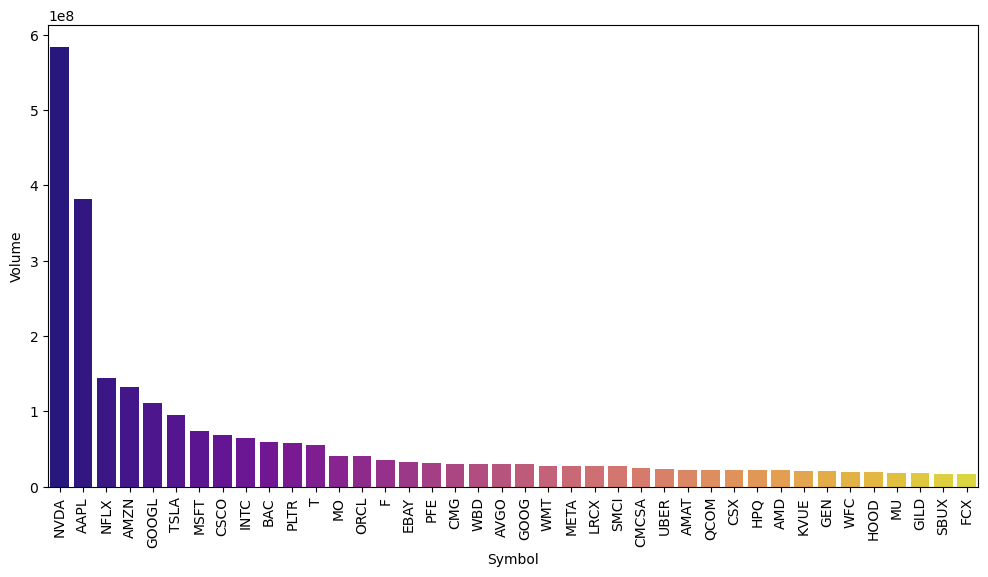

In [25]:
plt.figure(figsize=(12,6))
sns.barplot(data = avg_volume.sort_values(by='Volume',ascending=False).head(40),x='Symbol',y='Volume',palette='plasma')
plt.xticks(rotation=90);

### Highest traded stocks - Lets just visualize 15

This analysis and visualization highlights the stocks with the highest average daily trading volume, providing insight into the most liquid and actively traded securities in the market. High-volume stocks generally attract greater investor participation, offer better trade execution, and often serve as key indicators of overall market activity.

In [46]:
avg_volume.sort_values("Volume",ascending=False).head(15).round()

,Symbol,Volume
348,NVDA,584182135.0
1,AAPL,382251386.0
338,NFLX,144788958.0
31,AMZN,131934810.0
214,GOOGL,111033884.0
456,TSLA,95298222.0
327,MSFT,74474170.0
118,CSCO,69033235.0
247,INTC,64775004.0
52,BAC,59323035.0


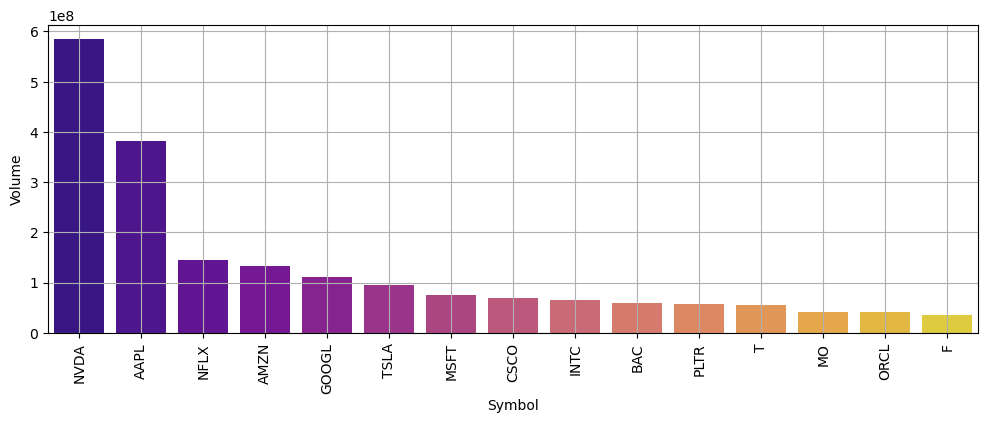

In [27]:
plt.figure(figsize=(12,4))
sns.barplot(data = avg_volume.sort_values("Volume",ascending=False).head(15).round(),
           x = 'Symbol',y='Volume',palette='plasma')
plt.xticks(rotation=90)
plt.grid();

# Candlestick Analysis

This analysis classifies each trading day as Bullish, Bearish, or Doji based on the relationship between opening and closing prices, enabling the examination of daily market sentiment and the identification of potential price movement patterns used in technical analysis.

In [28]:
import numpy as np

In [29]:
stocks["CandleType"] = np.select([stocks["Close"] > stocks["Open"],stocks["Close"] < stocks["Open"]],
    ["Bullish","Bearish"],default="Doji")

In [30]:
stocks.head()

,Date,Symbol,Open,High,Low,Close,Volume,PriceVariance,DailyReturn,MA20,MA50,Signal,CandleType
0,1999-11-18,A,29.5594,32.4842,25.9889,28.5858,6.886678e+07,6.4953,NaN,NaN,NaN,,Bearish
1,1999-11-19,A,27.8972,27.9371,25.8613,26.2311,1.677358e+07,2.0758,-0.082373,NaN,NaN,,Bearish
2,1999-11-22,A,26.8370,28.5858,26.0278,28.5858,7.242576e+06,2.5580,0.089767,NaN,NaN,,Bullish
3,1999-11-23,A,27.6102,28.3377,25.9889,25.9889,6.579458e+06,2.3488,-0.090846,NaN,NaN,,Bearish
4,1999-11-24,A,26.0637,27.2445,25.9889,26.6745,5.332648e+06,1.2556,0.026380,NaN,NaN,,Bullish


In [47]:
stocks['CandleType'].value_counts()

CandleType
Bullish    1715671
Bearish    1643158
Doji        149390
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='CandleType'>

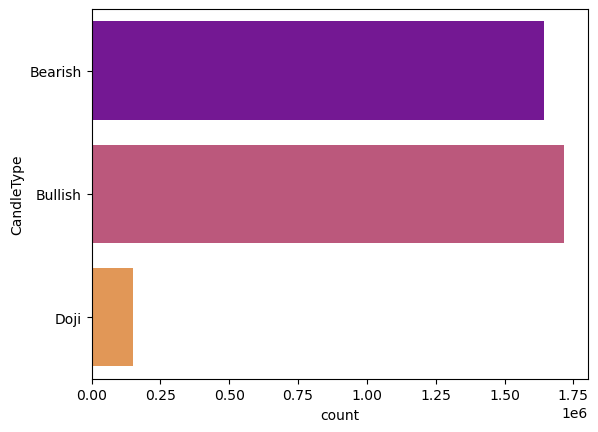

In [31]:
sns.countplot(data = stocks, y = stocks['CandleType'],palette='plasma')

# Answering Some Questions

## A) Which stocks are most volatile?

This analysis identifies and visualizes the twenty stocks with the highest standard deviation of daily returns, enabling comparison of relative risk levels across securities and highlighting stocks that experience the largest price fluctuations over time.

In [48]:
volatility.sort_values("DailyReturn",
                       ascending=False).head(20).groupby('Symbol').max().sort_values(by='DailyReturn')

,DailyReturn
Symbol,
CIEN,0.041932
BLDR,0.041991
TTD,0.043256
PLTR,0.044345
MRNA,0.045588
HOOD,0.046690
SMCI,0.049125
APP,0.049192
MNST,0.049421


<Axes: xlabel='Symbol'>

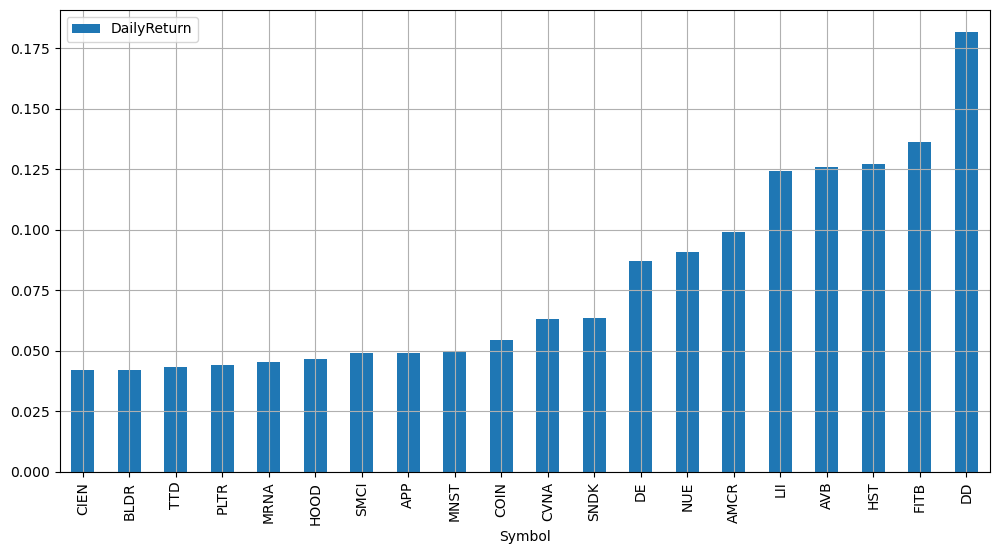

In [32]:
volatility.sort_values("DailyReturn",
                       ascending=False).head(20).groupby('Symbol').max().sort_values(by='DailyReturn').plot(kind='bar',
                                                                                                           figsize=(12,6),
                                                                                                          grid=True)

# 3) Which stocks have highest average volume?

This analysis identifies the 20 most actively traded stocks based on their average daily trading volume, providing insight into market liquidity, investor participation, and the ease with which shares can be bought or sold without significantly affecting market prices.

In [33]:
avg_volume.sort_values("Volume",ascending=False).round().head(20)

,Symbol,Volume
348,NVDA,584182135.0
1,AAPL,382251386.0
338,NFLX,144788958.0
31,AMZN,131934810.0
214,GOOGL,111033884.0
456,TSLA,95298222.0
327,MSFT,74474170.0
118,CSCO,69033235.0
247,INTC,64775004.0
52,BAC,59323035.0


# 4) What relationship exists between volume and volatility?

The correlation analysis examines whether trading activity is associated with stock price volatility. The correlation coefficient of -0.0218 indicates an extremely weak negative relationship between average trading volume and daily price variance, suggesting that trading volume has little to no meaningful influence on the magnitude of daily price fluctuations across the stocks in the dataset. Consequently, highly traded stocks are not necessarily more or less volatile than stocks with lower trading volumes.

In [34]:
stocks[['Volume','PriceVariance']].corr()

,Volume,PriceVariance
Volume,1.000000,-0.021844
PriceVariance,-0.021844,1.000000


<Axes: >

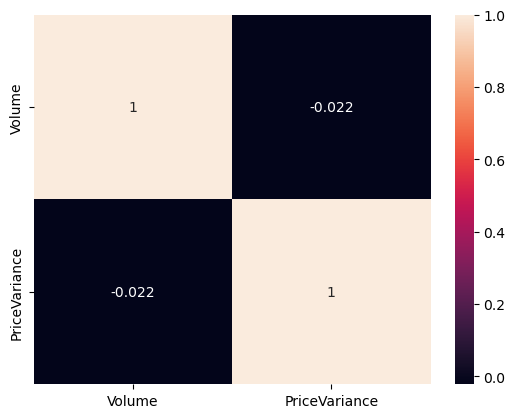

In [35]:
sns.heatmap(stocks[['Volume','PriceVariance']].corr(),annot=True)

# 5) Which stocks generate the most trading opportunities?

This analysis counts the number of BUY and SELL signals generated by the moving average crossover strategy (20-day and 50-day moving averages) for each stock. Stocks with higher numbers of signals exhibit more frequent trend changes and therefore provide more potential trading opportunities for investors and traders. By comparing the frequency of BUY and SELL signals across stocks, it becomes possible to identify securities that are more active from a technical trading perspective and may offer greater opportunities for entry and exit decisions.

In [36]:
df = (stocks.groupby(['Symbol','Signal']).size().unstack(fill_value=0))
df.head(20)

Signal,,BUY,SELL
Symbol,,,
A,49,3728,2833
AAPL,49,6344,4062
ABBV,49,2033,1231
ABNB,49,595,671
ABT,49,2442,1578
ACGL,50,3535,1705
ACN,49,3441,1800
ADBE,49,6008,3908
ADI,49,5908,4530


# 6) Are BUY signals associated with positive returns?

The average daily return was calculated for each trading signal category (BUY, SELL, and periods with no signal). The results indicate that days without a generated signal recorded the highest average return (0.0983%), followed by BUY signals (0.0775%) and SELL signals (0.0688%).

The findings imply that trading signals alone may not fully explain stock performance and should be combined with other indicators such as volatility, trading volume, or candlestick patterns for more robust investment decisions.

In [37]:
stocks.groupby('Signal')['DailyReturn'].mean()

Signal
        0.000983
BUY     0.000775
SELL    0.000688
Name: DailyReturn, dtype: float64

# 7) Which stocks are both volatile and highly traded?

This analysis combines average price variance (a measure of volatility) and average trading volume (a measure of market activity) for each stock. Stocks that rank highly on both metrics tend to experience larger price movements while also attracting substantial investor interest and liquidity.

In [38]:
stocks.groupby('Symbol').agg({'PriceVariance':'mean','Volume':'mean'}).round()

,PriceVariance,Volume
Symbol,,
A,1.0,3444385.0
AAPL,1.0,382251386.0
ABBV,2.0,8705980.0
ABNB,5.0,5693094.0
ABT,1.0,8078445.0
...,...,...
XYZ,4.0,10171813.0
YUM,1.0,4170969.0
ZBH,2.0,1638665.0


## Which stocks generate the most trading opportunities?

From this analysis, i can tell Which stocks trigger the highest number of BUY signals. Which stocks trigger the highest number of SELL signals and Which stocks experience the most trend reversals?

In [39]:
sigSummary = (
    stocks.groupby(['Symbol','Signal'])
    .size()
    .unstack(fill_value=0)
)

In [40]:
sigSummary

Signal,,BUY,SELL
Symbol,,,
A,49,3728,2833
AAPL,49,6344,4062
ABBV,49,2033,1231
ABNB,49,595,671
ABT,49,2442,1578
...,...,...,...
XYZ,49,1501,1038
YUM,49,4391,2721
ZBH,49,3459,2673


## How Has Market Volatility Changed Over Time?

This analysis examines how stock market volatility has evolved over the years by calculating the average daily price variance (difference between the daily high and low prices) across all stocks for each year. Plotting these yearly averages helps reveal periods of increased or reduced market uncertainty and price fluctuations.

In [54]:
stocks.groupby('Year')['PriceVariance'].mean()

Year
1962    0.070569
1963    0.050396
1964    0.048501
1965    0.056658
1966    0.086945
          ...   
2022    4.441482
2023    3.479647
2024    4.280101
2025    5.388819
2026    6.688322
Name: PriceVariance, Length: 65, dtype: float64

Text(0, 0.5, 'Average Price Variance')

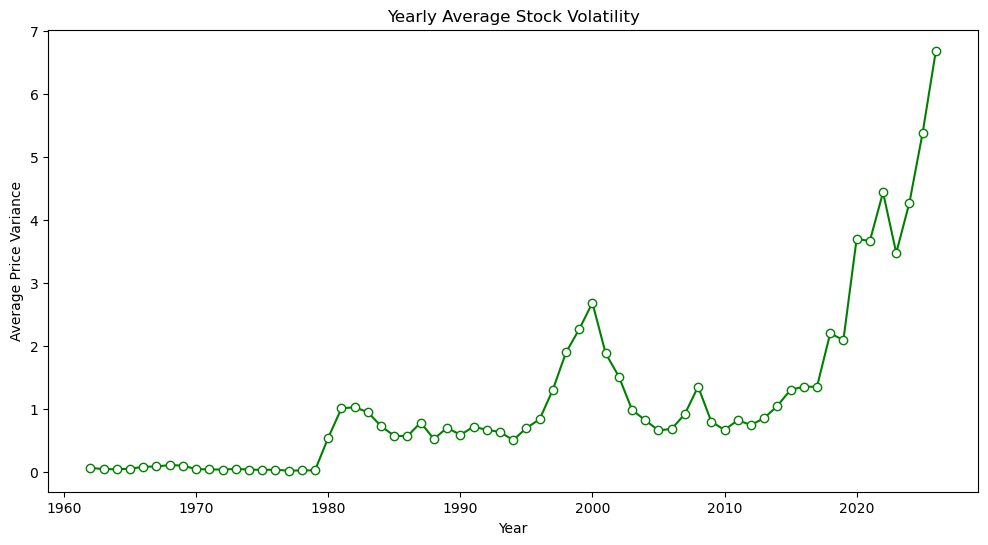

In [41]:
stocks['Year'] = stocks['Date'].dt.year

plt.figure(figsize=(12,6))
plt.plot((stocks.groupby('Year')['PriceVariance'].mean()),color='green',marker='o',markerfacecolor='w')
plt.title("Yearly Average Stock Volatility")
plt.xlabel("Year")
plt.ylabel("Average Price Variance")

# How Have Trading Volumes Changed Over Time?

This analysis examines the trend in average trading volume across all stocks over the years. Trading volume represents the number of shares exchanged during a trading session and serves as an indicator of market participation and liquidity. By aggregating average volumes on a yearly basis, it becomes possible to identify periods of increased or decreased investor activity. Rising trading volumes may indicate stronger market interest, higher liquidity, or increased speculative activity, while declining volumes may suggest reduced participation and lower market engagement.

In [55]:
stocks.groupby('Year')['Volume'].mean()

Year
1962    1.288477e+06
1963    7.366421e+05
1964    5.758370e+05
1965    4.731720e+05
1966    5.511418e+05
            ...     
2022    6.847033e+06
2023    6.152167e+06
2024    5.812350e+06
2025    6.450018e+06
2026    1.280940e+06
Name: Volume, Length: 65, dtype: float64

<Axes: title={'center': 'Yearly Average Trading Volume'}, xlabel='Year', ylabel='Average Volume'>

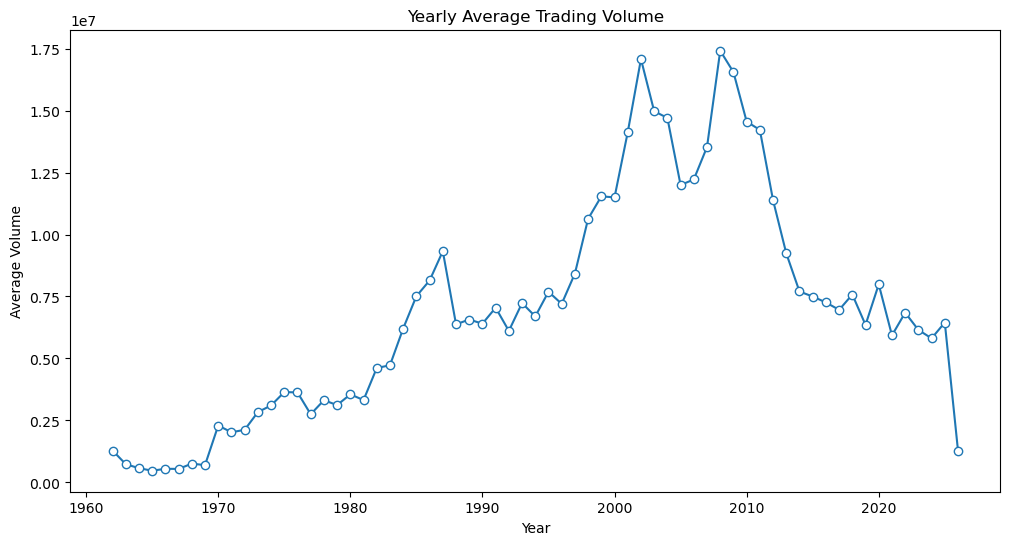

In [42]:
(stocks.groupby('Year')['Volume'].mean()).plot(marker='o',figsize=(12,6),
                                               title="Yearly Average Trading Volume",
                                              xlabel="Year",
                                               ylabel="Average Volume",
                                               markerfacecolor='w'
                                              )

# How Has Market Sentiment Changed Over Time?

This analysis measures the percentage of bullish candlesticks recorded each year across all stocks in the dataset. A bullish candlestick occurs when the closing price is higher than the opening price, indicating that buyers dominated trading during that session. By calculating the annual proportion of bullish trading days, the analysis provides an indication of overall market sentiment over time.

An upward trend in the chart suggests increasing investor optimism and stronger buying pressure, as a greater share of trading days end with price gains. Conversely, a downward trend indicates growing market pessimism and stronger selling activity.

In [57]:
stocks.groupby(stocks['Date'].dt.year)['Bullish'].mean().mul(100)

Date
1962    33.797217
1963    36.852590
1964    34.980237
1965    40.079365
1966    37.301587
          ...    
2022    50.047247
2023    51.784056
2024    50.722834
2025    51.503818
2026    54.460631
Name: Bullish, Length: 65, dtype: float64

<Axes: title={'center': 'Yearly Percentage of Bullish Candlesticks'}, xlabel='Year', ylabel='Bullish Candles (%)'>

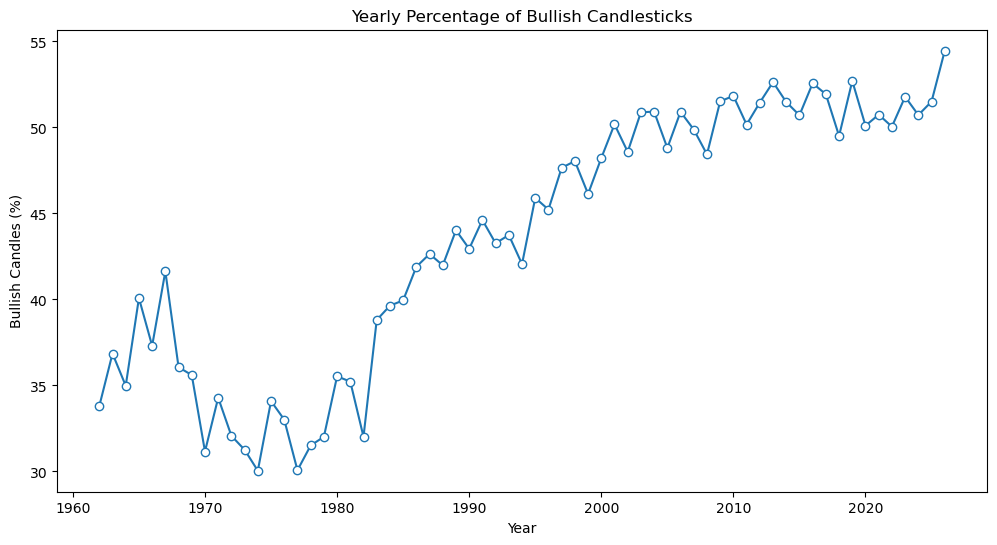

In [43]:
stocks['Bullish'] = stocks['CandleType'].eq('Bullish')

(stocks.groupby(stocks['Date'].dt.year)['Bullish']
 .mean()
 .mul(100)
).plot(
    marker='o',
    figsize=(12,6),
    title="Yearly Percentage of Bullish Candlesticks",
    xlabel="Year",
    ylabel="Bullish Candles (%)",
    markerfacecolor='w'
)